In [1]:
import pandas as pd
import numpy as np

In [2]:
def generate_MCAR(X, missing_column_name, missing_fraction=0.10, random_state=42):
    df_temp = X.copy()
    np.random.seed(random_state)
    n_count = len(df_temp)
    if not n_count:
        raise ValueError('Empty DataFrame')
    n_missing = int(missing_fraction * n_count)
    missing_index = np.random.choice(n_count, n_missing, replace=False)
    df_temp.loc[missing_index, missing_column_name] = np.nan
    return df_temp

In [3]:
def generate_MAR(X, missing_column_name, condition_column, missing_fraction=0.10, random_state=42):
    df_temp = X.copy()
    np.random.seed(random_state)
    condition_index = df_temp[df_temp[condition_column] == True].index
    n_count = len(condition_index)
    if not n_count:
        raise ValueError('No row satisfies the condition to be filled with NaN')
    n_missing = int(missing_fraction * n_count)
    missing_index = np.random.choice(condition_index, n_missing, replace=False)
    df_temp.loc[missing_index, missing_column_name] = np.nan
    df_temp.drop(columns=condition_column, inplace=True)
    return df_temp

### Imputation for Independent Features
- Most common: mean
- For skewed data/outliers: median
- For categorical data: mode

In [4]:
np.random.seed(42)
n_samples = 5000
outlier_frc = 0.05
outlier_count = int(n_samples * outlier_frc)
inliner_count = n_samples - outlier_count

# Column 'A': Symmetric
# Column 'B': Skewed
# Column 'C': Skewed with outliers
X = pd.DataFrame({
    'A' : np.random.randn(n_samples),
    'B' : np.random.lognormal(size=n_samples),
    'C' : np.concatenate([np.random.lognormal(size=inliner_count), 20 * np.ones(outlier_count)])
})

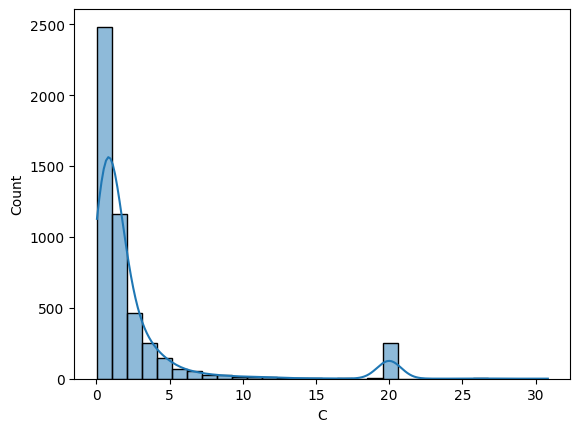

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.histplot(
    data=X['C'],
    bins=30,
    kde=True
)
plt.show()

In [6]:
MCAR = X.copy()
MCAR = generate_MCAR(MCAR, missing_column_name='A', missing_fraction=0.1, random_state=42)
MCAR = generate_MCAR(MCAR, missing_column_name='B', missing_fraction=0.1, random_state=43)
MCAR = generate_MCAR(MCAR, missing_column_name='C', missing_fraction=0.1, random_state=44)
MCAR.head()

,A,B,C
0,0.496714,0.654581,0.507380
1,-0.138264,0.635455,0.736755
2,0.647689,0.166021,0.550251
3,1.523030,0.718859,1.116745
4,-0.234153,2.080959,3.310763


In [7]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

In [8]:
X_mean_imputed = mean_imputer.fit_transform(MCAR)
X_median_imputed = median_imputer.fit_transform(MCAR)
X_mode_imputed = mode_imputer.fit_transform(MCAR)

In [9]:
X_mean_imputed

array([[ 0.49671415,  0.65458117,  0.50738016],
       [-0.1382643 ,  0.63545493,  0.7367553 ],
       [ 0.64768854,  0.16602064,  0.55025082],
       ...,
       [ 3.1129102 ,  0.4939521 , 20.        ],
       [ 0.80803619,  1.64175464, 20.        ],
       [-0.8480656 ,  1.90482179, 20.        ]], shape=(5000, 3))

In [10]:
# Reconstruction error
mse_mean_imputer = ((X-X_mean_imputed)**2).mean()
mse_median_imputer = ((X-X_median_imputed)**2).mean()
mse_mode_imputer = ((X-X_mode_imputed)**2).mean()

In [11]:
comparison_df = pd.DataFrame({
    'MEAN': mse_mean_imputer.values,
    'MEDIAN': mse_median_imputer.values,
    'MODE': mse_mode_imputer.values,
}, index=mse_mean_imputer.index)

- MSE will always be min for mean imputation 
- MAE will always be min for median imputation
- Median imputation is robust to outliers, does not mean low MSE

In [12]:
comparison_df

,MEAN,MEDIAN,MODE
A,0.097518,0.097590,1.135921
B,0.470371,0.522804,0.754510
C,2.168302,2.430635,32.108180


### Imputation for Dependent Features
- Simple
- kNN
- MICE

In [13]:
n_samples = 10000

# Create features
x = np.random.uniform(low=0, high=1, size=n_samples)
y = np.random.randn(n_samples)
z = 2 * x + y + np.sqrt(1e-4) * np.random.randn(n_samples)

# Create DataFrame
data = pd.DataFrame({
    'X' : x,
    'Y' : y,
    'Z' : z,
})
data.head()

,X,Y,Z
0,0.120280,-0.787330,-0.559301
1,0.854116,-1.076328,0.641695
2,0.474441,-0.437678,0.492488
3,0.940621,0.989131,2.866927
4,0.895548,1.165009,2.952979


In [14]:
MAR = data.copy()
MAR['MAR_condition_column'] = MAR['X'] < 0.1
MAR = generate_MAR(MAR, 'Z', 'MAR_condition_column', missing_fraction=0.01, random_state=42)
MAR = generate_MCAR(MAR, 'X', missing_fraction=0.02, random_state=43)
MAR = generate_MCAR(MAR, 'Y', missing_fraction=0.02, random_state=44)

MAR.isna().sum()

X    200
Y    200
Z     10
dtype: int64

In [15]:
# Simple Imputation
# Can also use sklearn.impute.SimpleImputer instead
values = {
    'X' : MAR['X'].mean(),
    'Y' : MAR['Y'].mean(),
    'Z' : MAR['Z'].mean(),
}
data_simple = MAR.fillna(value=values)

In [16]:
# KNN Imputation
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
data_knn = imputer.fit_transform(MAR)
data_knn = pd.DataFrame(
    data=data_knn,
    index=MAR.index,
    columns=MAR.columns
)
data_knn.head()

,X,Y,Z
0,0.120280,-0.787330,-0.559301
1,0.854116,-1.076328,0.641695
2,0.474441,-0.437678,0.492488
3,0.940621,0.989131,2.866927
4,0.895548,1.165009,2.952979


In [17]:
# MICE imputation
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(
    estimator=RandomForestRegressor(),
    max_iter=10,
    initial_strategy='mean'
    )
data_mice = imputer.fit_transform(MAR)
data_mice = pd.DataFrame(
    data=data_mice,
    index=MAR.index,
    columns=MAR.columns
)
data_mice.head()

c:\Users\vansh\Desktop\Practical ML\.venv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,X,Y,Z
0,0.120280,-0.787330,-0.559301
1,0.854116,-1.076328,0.641695
2,0.474441,-0.437678,0.492488
3,0.940621,0.989131,2.866927
4,0.895548,1.165009,2.952979


- Simple imputation is good when features are independent
- KNN performs better than simple when features are dependent
- MICE performs best when features are dependent, but computationally expensive

In [18]:
comparison_df = pd.DataFrame({
    'MEAN' : ((data - data_simple) ** 2).mean().values,
    'KNN' : ((data - data_knn) ** 2).mean().values,
    'MICE' : ((data - data_mice) ** 2).mean().values
}, index=['X', 'Y', 'Z'])
comparison_df

,MEAN,KNN,MICE
X,0.001823,0.000680,0.000067
Y,0.019034,0.002188,0.000191
Z,0.001869,0.001280,0.000067
